# Q7. Did net-migration dynamics diverge in sign and volatility after accession?

- **Purpose:** Human-capital flow signal.  
- **Plot:** *Distribution ribbons* of net migration (per 1 000) by group and period; *spike chart* around 2004/2007/2014.  
- **Method:** **Poisson or NegBin GLM (MLE)** for counts or FE OLS for rates.  
- **Test:** Entrant × Post coefficient; check over-dispersion.  
- **Expected:** Entrants trend less negative/more positive; UKR large negative post-2014.  
- **Pitfall:** Definition differences in modeled migration; document metadata.

In [1]:
import pandas as pd, numpy as np
import statsmodels.api as sm, statsmodels.formula.api as smf
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

sns.set(style="ticks")

In [9]:
base = Path("../data/proceed")
raw = pd.read_csv(base / "filtered_indicators.csv")


In [11]:
raw.head()

,Country_Name,Country_Code,Indicator_Name,Indicator_Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Belarus,BLR,Control of Corruption: Estimate,CC.EST,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.315615,-0.223862,-0.241236,-0.155491,0.006897,-0.134194,-0.258520,-0.579731,-0.665028,NaN
1,Belarus,BLR,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,25.600000,25.300000,25.400000,25.200000,25.300000,24.400000,NaN,NaN,NaN,NaN
2,Belarus,BLR,Government Effectiveness: Estimate,GE.EST,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.489229,-0.513944,-0.357744,-0.297943,-0.174483,-0.829658,-0.804154,-0.851723,-0.991466,NaN
3,Belarus,BLR,Income share held by highest 20%,SI.DST.05TH.20,NaN,NaN,NaN,NaN,NaN,NaN,...,35.400000,35.400000,35.500000,35.500000,35.400000,34.800000,NaN,NaN,NaN,NaN
4,Belarus,BLR,Income share held by lowest 20%,SI.DST.FRST.20,NaN,NaN,NaN,NaN,NaN,NaN,...,9.700000,9.900000,9.900000,10.100000,10.000000,10.300000,NaN,NaN,NaN,NaN


In [12]:
# --- Identify year columns dynamically ---
year_cols = [c for c in raw.columns if c.isdigit()]
print("Year columns detected:", year_cols[:10], "... total:", len(year_cols))

# --- Melt (wide → long) ---
long = (
    raw.melt(
        id_vars=["Country_Name", "Country_Code", "Indicator_Name", "Indicator_Code"],
        value_vars=year_cols,
        var_name="year",
        value_name="value"
    )
)

# --- Clean types ---
long["year"] = long["year"].astype(int)
long = long.rename(columns={
    "Country_Name": "country",
    "Country_Code": "country_code",
    "Indicator_Name": "indicator",
    "Indicator_Code": "indicator_code"
})

# Drop rows with all-NaN or empty values
long = long.dropna(subset=["value"]).reset_index(drop=True)

print(long.head(10))
print("Shape:", long.shape)

Year columns detected: ['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969'] ... total: 65
              country country_code      indicator indicator_code  year  \
0             Belarus          BLR  Net migration    SM.POP.NETM  1960   
1             Czechia          CZE  Net migration    SM.POP.NETM  1960   
2              Poland          POL  Net migration    SM.POP.NETM  1960   
3  Russian Federation          RUS  Net migration    SM.POP.NETM  1960   
4     Slovak Republic          SVK  Net migration    SM.POP.NETM  1960   
5             Ukraine          UKR  Net migration    SM.POP.NETM  1960   
6             Belarus          BLR  Net migration    SM.POP.NETM  1961   
7             Czechia          CZE  Net migration    SM.POP.NETM  1961   
8              Poland          POL  Net migration    SM.POP.NETM  1961   
9  Russian Federation          RUS  Net migration    SM.POP.NETM  1961   

      value  
0  -27382.0  
1    2748.0  
2   -6306.0  
3 -234895.0

In [13]:
outpath = base / "filtered_indicators_long.csv"
long.to_csv(outpath, index=False)

In [14]:
W = pd.read_csv(base / "filtered_indicators_long.csv")

In [15]:
R = pd.read_csv(base / "interest_rate.csv")

In [16]:
W.head()

,country,country_code,indicator,indicator_code,year,value
0,Belarus,BLR,Net migration,SM.POP.NETM,1960,-27382.0
1,Czechia,CZE,Net migration,SM.POP.NETM,1960,2748.0
2,Poland,POL,Net migration,SM.POP.NETM,1960,-6306.0
3,Russian Federation,RUS,Net migration,SM.POP.NETM,1960,-234895.0
4,Slovak Republic,SVK,Net migration,SM.POP.NETM,1960,4344.0


In [17]:
R.head()

,Country_Name,Country_Code,Indicator_Name,Indicator_Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Belarus,BLR,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.5,99.5,99.6,99.7,99.7,99.7,99.7,99.7,NaN,NaN
1,Belarus,BLR,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,98.3,98.6,98.7,98.9,99.0,99.1,99.2,99.3,NaN,NaN
2,Belarus,BLR,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.9,99.9,99.9,99.9,99.9,99.9,99.9,99.8,NaN,NaN
3,Belarus,BLR,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.4,98.0,98.7,99.3,100.0,100.0,100.0,100.0,100.0,NaN
4,Belarus,BLR,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,93.1,94.7,96.6,98.2,100.0,100.0,100.0,100.0,100.0,NaN


In [18]:
W = W.rename(columns={
    "Country Code":"country_code", "Country Name":"country",
    "Indicator Code":"indicator_code", "Indicator Name":"indicator"
})
W["year"] = W["year"].astype(int)

# --- Detect likely codes present in your file ---
NET_CODES = ["SM.POP.NETM", "POP.NETM"]         # net migration (count)
POP_CODES = ["SP.POP.TOTL", "POP.TOTL"]         # total population
code_set = set(W["indicator_code"].unique())

has_net = any(c in code_set for c in NET_CODES)
has_pop = any(c in code_set for c in POP_CODES)

print("Has net-migration?:", has_net, "Has population?:", has_pop)

Has net-migration?: True Has population?: False


Build country-year panel

In [19]:
EU = ["POL","CZE","SVK"]
NON_EU = ["RUS","UKR","BLR"]
ACCES_YEAR = {"POL":2004, "CZE":2004, "SVK":2004}  # your entrants here

# Pull needed series present
need_codes = [c for c in NET_CODES if c in code_set] + [c for c in POP_CODES if c in code_set]
df = W[W["indicator_code"].isin(need_codes)].copy()

# Long->wide
code_to_key = {**{c:"NetMig" for c in NET_CODES}, **{c:"Population" for c in POP_CODES}}
df["ind_key"] = df["indicator_code"].map(code_to_key)
wide = (df.pivot_table(index=["country_code","country","year"],
                       columns="ind_key", values="value", aggfunc="mean")
          .reset_index())

# Trim to your six countries and a reasonable window
wide = wide.query("country_code in @EU or country_code in @NON_EU").copy()
wide = wide.query("1990 <= year <= 2024").sort_values(["country_code","year"])
wide["EU"] = wide["country_code"].isin(EU).astype(int)

# Accession flags
wide["post"] = 0
for c in EU:
    wide.loc[(wide["country_code"]==c) & (wide["year"]>=ACCES_YEAR[c]), "post"] = 1
wide["treat"] = wide["EU"] * wide["post"]

# Merge interest rate if available (optional control)
if set(["country_code","year"]).issubset(R.columns):
    wide = wide.merge(R.rename(columns={"rate":"interest_rate"}),
                      on=["country_code","year"], how="left")
else:
    wide["interest_rate"] = np.nan

# Clean numeric
for col in ["NetMig","Population","interest_rate"]:
    if col in wide.columns:
        wide[col] = pd.to_numeric(wide[col], errors="coerce")


create the migration rate 

In [20]:
if "Population" in wide.columns and "NetMig" in wide.columns:
    wide["mig_rate_per1k"] = (wide["NetMig"] / wide["Population"]) * 1000.0
else:
    # fallback: if only NetMig exists, scale by country mean pop proxy (risky) or center within-country
    if "NetMig" in wide.columns:
        wide["mig_rate_per1k"] = wide.groupby("country_code")["NetMig"].transform(
            lambda s: (s - s.mean()) / (s.std(ddof=1) + 1e-9)
        )
        print("Population not found—using within-country standardized NetMig as a proxy rate.")
    else:
        raise ValueError("Net migration series not found in filtered_indicators.csv")


Population not found—using within-country standardized NetMig as a proxy rate.


In [22]:
models = {}

In [23]:
d2 = wide.dropna(subset=["mig_rate_per1k","treat"]).copy()
formula = "mig_rate_per1k ~ treat + C(country_code) + C(year)"
fit_fe = smf.ols(formula, data=d2).fit(
    cov_type="cluster", cov_kwds={"groups": d2["country_code"]}
)
models["FE_rate"] = fit_fe
print(fit_fe.summary())


                            OLS Regression Results                            
Dep. Variable:         mig_rate_per1k   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                -6.480e+11
Date:                Wed, 22 Oct 2025   Prob (F-statistic):               1.00
Time:                        20:40:26   Log-Likelihood:                -272.95
No. Observations:                 210   AIC:                             627.9
Df Residuals:                     169   BIC:                             765.1
Df Model:                          40                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 5
  warnings.warn('covariance of constraints does not have full '


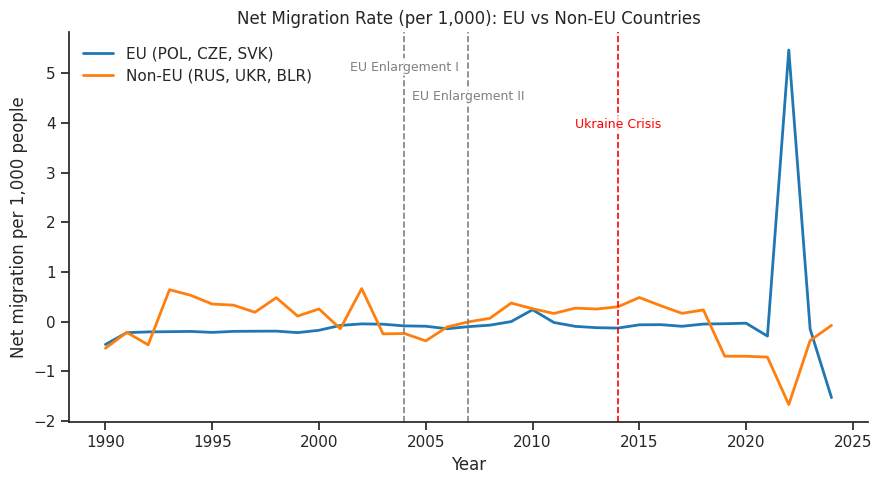

In [33]:
fig, ax = plt.subplots(figsize=(9,5))

# --- Plot group means ---
for g, lab, col in [(1,"EU (POL, CZE, SVK)","tab:blue"),
                    (0,"Non-EU (RUS, UKR, BLR)","tab:orange")]:
    m = (wide[wide["EU"]==g]
         .groupby("year")["mig_rate_per1k"].mean()
         .reset_index())
    ax.plot(m["year"], m["mig_rate_per1k"], label=lab, color=col, lw=2)

# --- Key events and labels ---
events = [
    (2004, "EU Enlargement I", "gray"),
    (2007, "EU Enlargement II", "gray"),
    (2014, "Ukraine Crisis", "red")
]

# Define staggered y positions (relative to axis height)
ymax = ax.get_ylim()[1]
y_positions = [ymax*0.88, ymax*0.78, ymax*0.68]  # vertically spaced

for (year, label, color), y in zip(events, y_positions):
    ax.axvline(year, color=color, ls="--", lw=1.2)
    ax.text(year, y, label,
            color=color, fontsize=9,
            ha="center", va="center",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5))

# --- Titles & labels ---
ax.set_title("Net Migration Rate (per 1,000): EU vs Non-EU Countries", fontsize=12)
ax.set_ylabel("Net migration per 1,000 people")
ax.set_xlabel("Year")
ax.legend(frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()


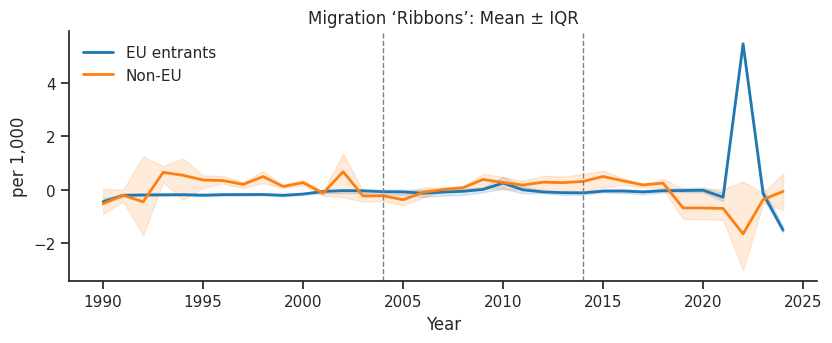

In [25]:
wide["period"] = np.where(wide["year"] < 2004, "Pre-2004", "Post-2004")
g = (wide.groupby(["EU","period","year"])["mig_rate_per1k"]
         .agg(["mean","quantile"]).reset_index())

# Easier: plot mean ± IQR by group using rolling window
fig, ax = plt.subplots(figsize=(8.5,3.6))
for eu, lab, col in [(1,"EU entrants","tab:blue"), (0,"Non-EU","tab:orange")]:
    sub = wide[wide["EU"]==eu].groupby("year")["mig_rate_per1k"]
    mean = sub.mean()
    lo = sub.quantile(0.25); hi = sub.quantile(0.75)
    ax.plot(mean.index, mean.values, color=col, lw=2, label=lab)
    ax.fill_between(mean.index, lo.values, hi.values, color=col, alpha=0.15)
ax.axvline(2004, color="gray", ls="--", lw=1); ax.axvline(2014, color="gray", ls="--", lw=1)
ax.set_title("Migration ‘Ribbons’: Mean ± IQR"); ax.set_ylabel("per 1,000"); ax.set_xlabel("Year")
ax.legend(frameon=False); sns.despine(); plt.tight_layout(); plt.show()


In [27]:
# Rolling 5y SD per country, then average by group
def roll_sd(s, w=5): return s.rolling(w, min_periods=3).std()

tmp = (wide.sort_values(["country_code","year"])
            .groupby("country_code")
            .apply(lambda g: pd.DataFrame({
                "year": g["year"],
                "EU": g["EU"].iloc[0],
                "roll_sd": roll_sd(g["mig_rate_per1k"])
            })).reset_index())

pre = tmp[tmp["year"]<2004].groupby("EU")["roll_sd"].mean()
post = tmp[tmp["year"]>=2004].groupby("EU")["roll_sd"].mean()
print("Average rolling SD (pre):\n", pre)
print("Average rolling SD (post):\n", post)

# Simple variance test (Levene) on country-level SD pre vs post
from scipy.stats import levene
pre_vals  = tmp[tmp["year"]<2004].groupby("country_code")["roll_sd"].mean().dropna()
post_vals = tmp[tmp["year"]>=2004].groupby("country_code")["roll_sd"].mean().dropna()
print("Levene pre vs post (all countries):", levene(pre_vals, post_vals, center='median'))


Average rolling SD (pre):
 EU
0    0.768358
1    0.066634
Name: roll_sd, dtype: float64
Average rolling SD (post):
 EU
0    0.465546
1    0.453055
Name: roll_sd, dtype: float64
Levene pre vs post (all countries): LeveneResult(statistic=np.float64(1.7737013865168596), pvalue=np.float64(0.21248255102047872))


/tmp/ipykernel_82219/3437285691.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.DataFrame({
